In [3]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd

nltk.download('vader_lexicon')

df = pd.read_csv("spotify_millsongdata.csv")

additional_df = pd.read_csv("additional_features.csv")

vds = SentimentIntensityAnalyzer()

records = []
for _, row in df.iterrows():
    scores = vds.polarity_scores(str(row["text"]))
    records.append({
        "Song":     row["song"],
        "Artist":   row["artist"],
        "Compound": scores["compound"],
        "Negative":      scores["neg"],
        "Neutral":      scores["neu"],
        "Positive":      scores["pos"],
    })

sentiment_df = pd.DataFrame(records)

merged_df = pd.merge(sentiment_df, additional_df, how="inner", left_on="Song", right_on="track_name")

# Drop duplicate song name column if needed
merged_df.drop(columns=["Unnamed: 0", "track_id", "duration_ms", "time_signature", "track_name", "artists"], inplace=True)

# Save merged dataset to CSV
merged_df.to_csv("merged_spotify_dataset.csv", index=False)

print("Merged dataset saved as 'merged_spotify_dataset.csv'")

print(merged_df.columns)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/shayna/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Merged dataset saved as 'merged_spotify_dataset.csv'
Index(['Song', 'Artist', 'Compound', 'Negative', 'Neutral', 'Positive',
       'album_name', 'popularity', 'explicit', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'track_genre'],
      dtype='object')


In [4]:
# For local AI implementation


# Install required packages (if not already installed)
# !pip install transformers sentence-transformers accelerate

import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

# Load BGE model + tokenizer
model_name = "BAAI/bge-large-en-v1.5"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Load VADER sentiment analyzer
vader = SentimentIntensityAnalyzer()

# Function to convert user input into Spotify-like feature dictionary
def get_song_features(user_input):
    # Get VADER sentiment scores
    sentiment = vader.polarity_scores(user_input)

    # Embed using BGE (optional for future ML use)
    prompt = "Represent this sentence for searching relevant passages: " + user_input
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
        embedding = outputs.last_hidden_state[:, 0]
        embedding = torch.nn.functional.normalize(embedding, p=2, dim=1)

    # Heuristically generate a song feature vector
    features = {
        "Compound": sentiment["compound"],
        "Negative": sentiment["neg"],
        "Neutral": sentiment["neu"],
        "Positive": sentiment["pos"],
        "artists": "User Generated",
        "album_name": "User Mood Album",
        "track_name": "User Mood Track",
        "popularity": 50,
        "explicit": False,
        "danceability": 0.5,
        "energy": 0.5,
        "key": 0,
        "loudness": -12.0,
        "mode": 1,
        "speechiness": 0.1,
        "acousticness": 0.7,
        "instrumentalness": 0.2,
        "liveness": 0.2,
        "valence": 0.6,
        "tempo": 100.0,
        "track_genre": "pop"
    }

    return features

# Get user input
user_input = input("Describe the kind of music you're in the mood for: ")
feature_dict = get_song_features(user_input)

print("\nGenerated Feature Vector:")
for k, v in feature_dict.items():
    print(f"{k}: {v}")



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/shayna/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



Generated Feature Vector:
Compound: 0.7184
Negative: 0.0
Neutral: 0.455
Positive: 0.545
artists: User Generated
album_name: User Mood Album
track_name: User Mood Track
popularity: 50
explicit: False
danceability: 0.5
energy: 0.5
key: 0
loudness: -12.0
mode: 1
speechiness: 0.1
acousticness: 0.7
instrumentalness: 0.2
liveness: 0.2
valence: 0.6
tempo: 100.0
track_genre: pop


In [7]:

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

device         = "cuda" if torch.cuda.is_available() else "cpu"
embedder       = SentenceTransformer("BAAI/bge-large-en-v1.5", device=device)
regressor      = Ridge()


def row_to_description(row):
    return (f"A {row['track_genre']} song called '{row['Song']}' by {row['Artist']} "
            f"that is {'explicit' if row['explicit'] else 'not explicit'}, "
            f"has a popularity score of {row['popularity']:.0f}, "
            f"and is known for {'high' if row['energy'] > 0.6 else 'low'} energy "
            f"and {'high' if row['acousticness'] > 0.6 else 'low'} acousticness.")

descriptions = merged_df.apply(row_to_description, axis=1).tolist()

print("Generating embeddings...")
X_embeddings = embedder.encode(
    descriptions,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

feature_cols = [
    'Compound', 'Negative', 'Neutral', 'Positive',
    'danceability', 'energy', 'key', 'loudness',
    'mode', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo'
]
y = merged_df[feature_cols].values

X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings, y, test_size=0.2, random_state=42
)

print("Training regression model...")
regressor.fit(X_train, y_train)
print(f"Model training complete. R² on test set: {regressor.score(X_test, y_test):.3f}")

def predict_user_query_features(user_input: str):
    desc        = [user_input]
    query_emb   = embedder.encode(desc, convert_to_numpy=True, normalize_embeddings=True)
    preds       = regressor.predict(query_emb)[0]
    return dict(zip(feature_cols, preds))

user_query = "I'm in a romantic mood, and I want a calm, acoustic love song with soft vocals."
predicted_features = predict_user_query_features(user_query)
print("\nPredicted feature vector:")
for feature, value in predicted_features.items():
    print(f"{feature}: {value:.3f}")


Generating embeddings...


Batches: 100%|██████████| 1036/1036 [24:23<00:00,  1.41s/it]


Training regression model...
Model training complete. R² on test set: 0.400

Predicted feature vector:
Compound: 0.994
Negative: 0.037
Neutral: 0.547
Positive: 0.416
danceability: 0.510
energy: 0.197
key: 7.095
loudness: -12.984
mode: 0.944
speechiness: 0.042
acousticness: 0.711
instrumentalness: -0.037
liveness: 0.051
valence: 0.460
tempo: 124.759


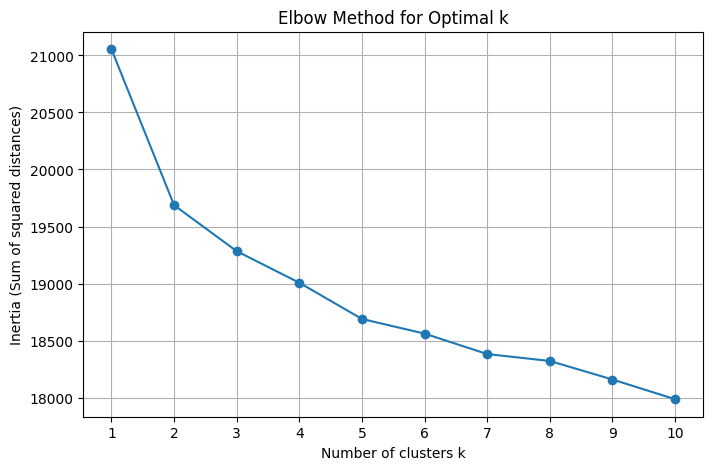

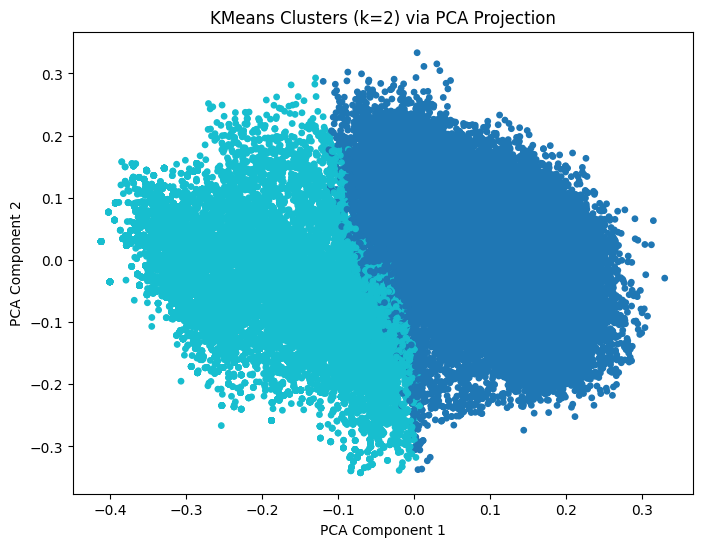

            Song           Artist
0     Break Free           Europe
1     Break Free  Hillsong United
2        Problem    Ariana Grande
3         Higher    Ariana Grande
4      Sometimes    Ariana Grande
5     Break Free     Kelly Family
6       December    Ariana Grande
7     Be Alright    Ariana Grande
8      True Love    Ariana Grande
9  One Last Time    Ariana Grande


In [15]:
#testing k means by feeding in outputs of the embeddings here
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sse = []
ks  = range(1, 11)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42).fit(X_embeddings)
    sse.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(ks), sse, 'o-', markersize=6)
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia (Sum of squared distances)')
plt.title('Elbow Method for Optimal k')
plt.xticks(ks)
plt.grid(True)
plt.show()

optimal_k =2

kmeans = KMeans(n_clusters=optimal_k, random_state=42).fit(X_embeddings)
labels = kmeans.labels_

pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=15)
plt.title(f'KMeans Clusters (k={optimal_k}) via PCA Projection')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

def find_nearest_songs(song_title, df, embeddings, kmeans_model, artist=None, k=10):
    if artist:
        mask = (
            df['Song'].str.lower() == song_title.lower()
        ) & (
            df['Artist'].str.lower() == artist.lower()
        )
    else:
        mask = df['Song'].str.lower() == song_title.lower()
    match = df[mask]
    if match.empty:
        print(f"Track '{song_title}'" + (f" by '{artist}'" if artist else "") + " not found.")
        return pd.DataFrame(columns=['Song','Artist'])
    
    idx = match.index[0]
    emb = embeddings[idx]
    label = kmeans_model.labels_[idx]
    
    cluster_idxs = np.where(kmeans_model.labels_ == label)[0]
    dists = np.linalg.norm(embeddings[cluster_idxs] - emb, axis=1)
    
    sorted_idxs = cluster_idxs[np.argsort(dists)]
    candidates = df.loc[sorted_idxs, ['Song','Artist']]
    unique = candidates.drop_duplicates(subset=['Song','Artist']).iloc[1:k+1]  # skip self
    
    return unique.reset_index(drop=True)

neighbors = find_nearest_songs("Break Free", merged_df, X_embeddings, kmeans, artist="Ariana Grande", k=10)
print(neighbors)


 

In [17]:
#dynamic query processing

import numpy as np
from sentence_transformers import SentenceTransformer

def process_user_query(query_text, k=10):
    query_emb = embedder.encode(
        [query_text],
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    
    pred_feats = regressor.predict(query_emb)[0]
    print("Predicted feature vector:")
    for name, val in zip(feature_cols, pred_feats):
        print(f"  {name}: {val:.3f}")
    
    cluster_label = kmeans.predict(query_emb)[0]
    print(f"\nAssigned to cluster: {cluster_label}")
    
    cluster_idxs = np.where(kmeans.labels_ == cluster_label)[0]
    dists = np.linalg.norm(X_embeddings[cluster_idxs] - query_emb, axis=1)
    nearest = cluster_idxs[np.argsort(dists)[:k]]
    neighbors = merged_df.iloc[nearest][['Song','Artist']].reset_index(drop=True)
    
    print(f"\nTop {k} nearest songs in the same cluster:")
    print(neighbors)

while True:
    q = input("Describe the kind of music you're in the mood for: ")
    if q.lower() == 'quit':
        break
    process_user_query(q, k=10)


<>:30: SyntaxWarning: invalid escape sequence '\D'
<>:30: SyntaxWarning: invalid escape sequence '\D'
/var/folders/xz/0z101vsx6474g61nnqqh5x8w0000gn/T/ipykernel_12288/449654384.py:30: SyntaxWarning: invalid escape sequence '\D'
  q = input("\Describe the kind of music you're in the mood for: ")


Predicted feature vector:
  Compound: 0.116
  Negative: 0.074
  Neutral: 0.709
  Positive: 0.217
  danceability: 0.701
  energy: 0.475
  key: 7.871
  loudness: -7.630
  mode: 0.403
  speechiness: 0.136
  acousticness: 0.536
  instrumentalness: 0.080
  liveness: 0.196
  valence: 0.604
  tempo: 136.219

Assigned to cluster: 0

Top 10 nearest songs in the same cluster:
                Song         Artist
0            Problem  Ariana Grande
1         Be Alright  Ariana Grande
2         Be Alright  Ariana Grande
3  Thinking Bout You  Ariana Grande
4         Break Free  Ariana Grande
5          Sometimes  Ariana Grande
6             Higher  Ariana Grande
7          Here I Am    Nicki Minaj
8          Sometimes  Ariana Grande
9          Sometimes  Ariana Grande
Predicted feature vector:
  Compound: 0.421
  Negative: 0.080
  Neutral: 0.677
  Positive: 0.243
  danceability: 0.788
  energy: 0.619
  key: 5.760
  loudness: -5.943
  mode: 0.533
  speechiness: 0.089
  acousticness: 0.263
  instrumen

In [ ]:
sentiment_df.dropna(subset=['Compound', 'Negative', 'Neutral', 'Positive'], inplace=True)
sentiment_df.drop_duplicates(subset=['Song', 'Artist'], inplace=True)

sentiment_df.to_csv("spotify_sentiment_scores.csv", index=False)

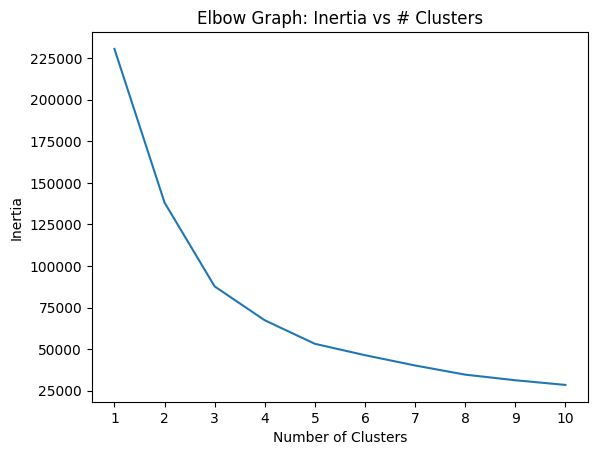

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

def plot_elbow_curve(df: pd.DataFrame, feature_cols: list[str], num_iterations=10, num_max_iter=300):
    scaler = StandardScaler()
    X = scaler.fit_transform(df[feature_cols])

    sse = []
    for k in range(1, 11):
        km = KMeans(
            n_clusters=k,
            n_init=num_iterations,
            max_iter=num_max_iter,
            random_state=42
        )
        km.fit(X)
        sse.append(km.inertia_)

    plt.plot(range(1, 11), sse)
    plt.xticks(range(1, 11))
    plt.xlabel('Number of Clusters')
    plt.ylabel('Inertia')
    plt.title('Elbow Graph: Inertia vs # Clusters')
    plt.show()

    return X

feature_cols = ['Compound', 'Negative', 'Neutral', 'Positive']
X = plot_elbow_curve(sentiment_df, feature_cols)



In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=100)
sentiment_df['cluster'] = kmeans.fit_predict(X)

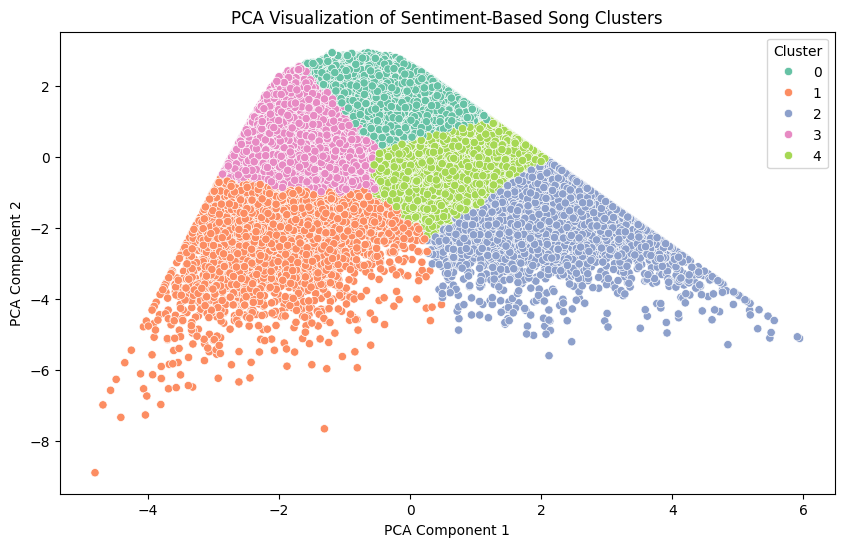

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

sentiment_df["pca1"] = pca_result[:, 0]
sentiment_df["pca2"] = pca_result[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sentiment_df, x="pca1", y="pca2", hue="cluster", palette="Set2")
plt.title("PCA Visualization of Sentiment-Based Song Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

In [ ]:
from sklearn.metrics.pairwise import euclidean_distances

def recommend_similar_songs(song_name: str, artist_name: str, df: pd.DataFrame, num_recommendations: int = 10) -> pd.DataFrame:
    # Find the song by both name and artist
    match = df[(df['Song'] == song_name) & (df['Artist'] == artist_name)]
    
    if match.empty:
        raise ValueError(f"Song '{song_name}' by artist '{artist_name}' not found in dataset.")
    
    # Get the row of the input song
    input_song_row = match.iloc[0]
    
    # Find the cluster of the input song
    target_cluster = input_song_row['cluster']
    
    # Filter songs in the same cluster
    cluster_df = df[df['cluster'] == target_cluster].copy()
    
    # Drop the input song from the list of candidates
    cluster_df = cluster_df[~((cluster_df['Song'] == song_name) & (cluster_df['Artist'] == artist_name))]

    # Extract the feature vectors for distance calculation
    features = ['Compound', 'Negitive', 'Neutral', 'Positive']
    input_vector = input_song_row[features].values.reshape(1, -1)
    cluster_vectors = cluster_df[features].values

    # Calculate distances
    distances = euclidean_distances(input_vector, cluster_vectors)[0]
    
    # Add distances to the cluster DataFrame
    cluster_df['distance'] = distances
    
    # Sort and return top N closest songs
    recommended = cluster_df.sort_values(by='distance').head(num_recommendations)
    return recommended[['Song', 'Artist', 'distance']]

In [ ]:
recommendations = recommend_similar_songs("Heartless", "Kanye West", sentiment_df)
print(recommendations)

                               Song            Artist  distance
46315                 The Wickedest  Notorious B.I.G.  0.003407
56627                    Release Me   Wilson Phillips  0.004110
40432  Here Come The People In Grey             Kinks  0.004915
40737                    Beg For Me              Korn  0.005262
18427        The Way The Wind Blows              Rush  0.007281
32718      The Feast And The Famine      Foo Fighters  0.007609
13463                     Annie Mae      Natalie Cole  0.008105
48713                      Haunting            Pogues  0.008603
32945             Cocaine Decisions       Frank Zappa  0.009424
50111  I'm Gonna Have A Little Talk      Randy Travis  0.009918
